 Intelligent Image Processing System 
This system performs preprocessing, enhancement, segmentation,
feature extraction, and evaluation of images.



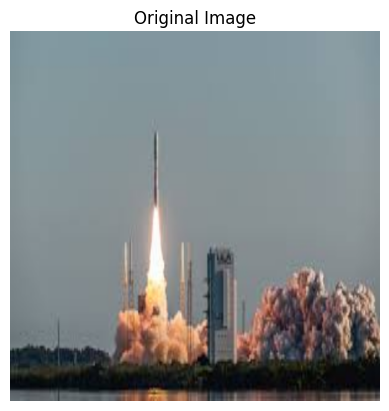

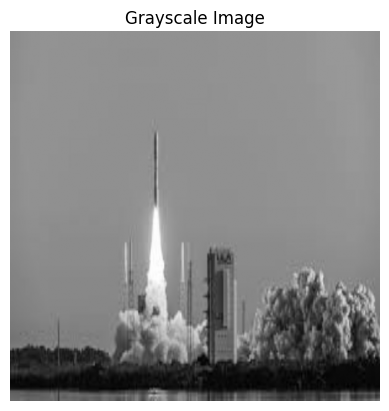

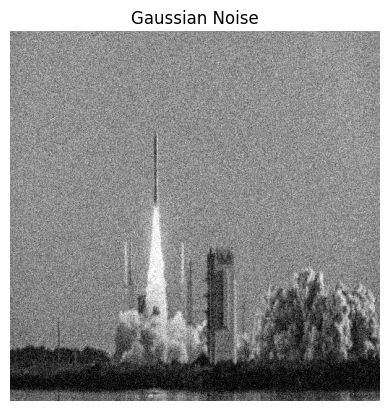

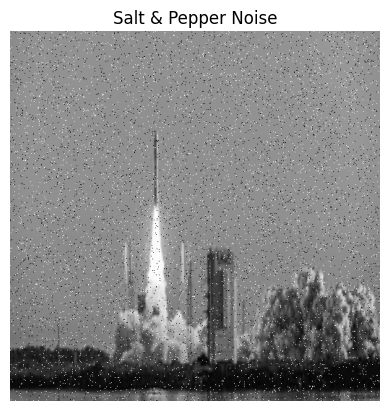

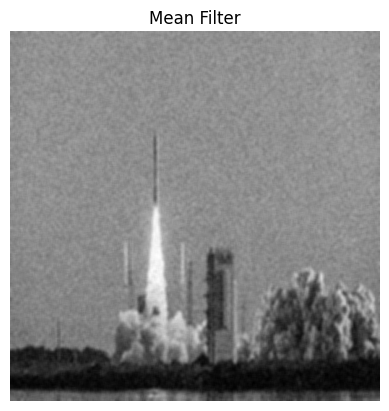

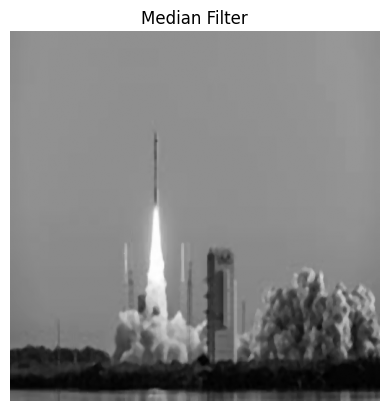

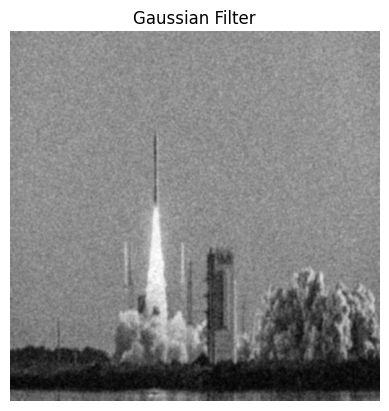

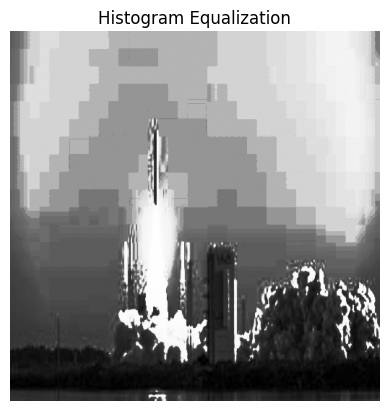

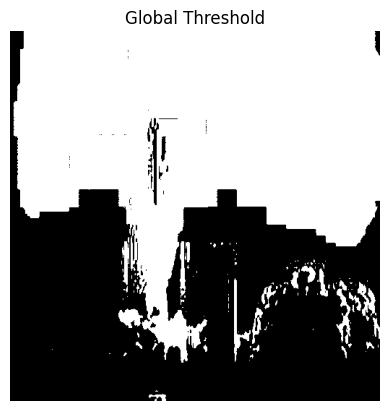

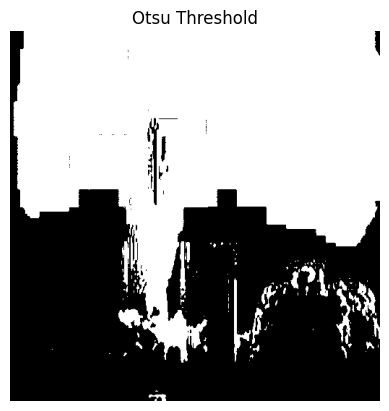

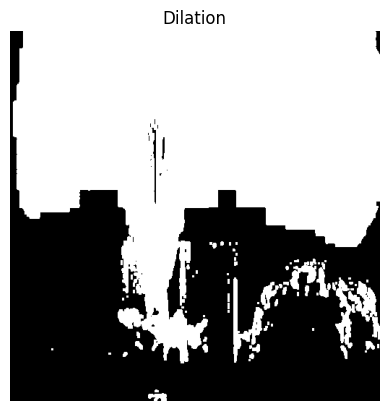

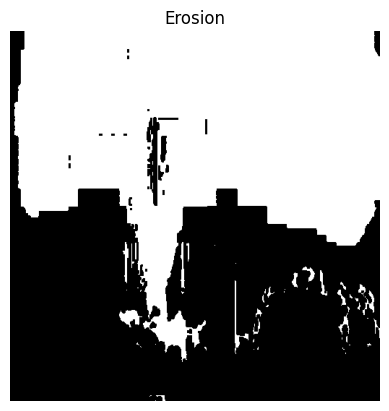

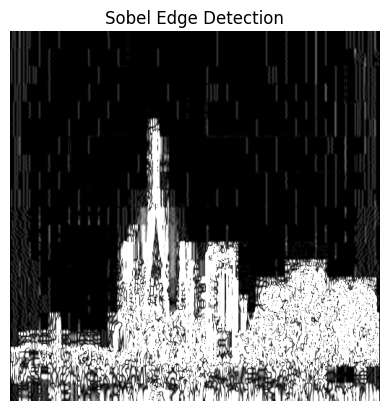

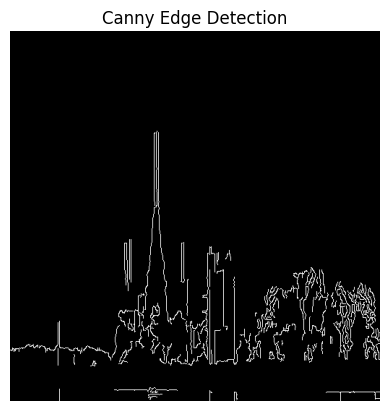

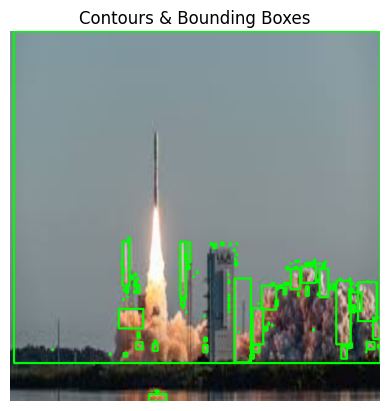

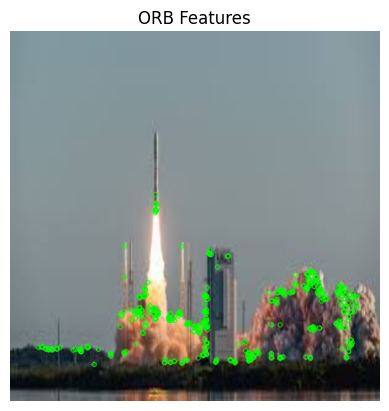


Performance Evaluation:
MSE: 43.66720962524414
PSNR: 31.72924919875745
SSIM: 0.6802423625545517


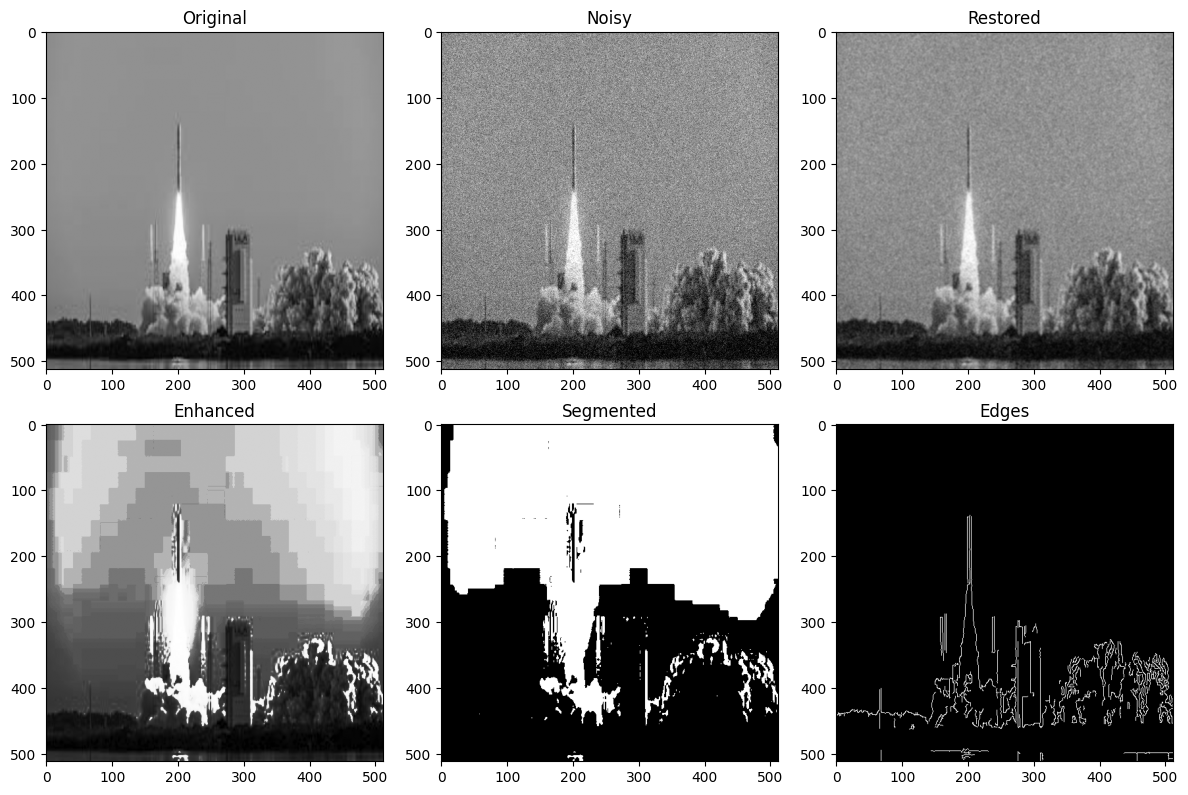


All outputs saved in 'outputs/' folder.
System execution completed successfully!

Conclusion:
The system successfully performed image preprocessing, enhancement,
segmentation, feature extraction, and evaluation.


In [2]:
"""
Student Name: Sagar
Roll No: 2301010312
Course Name: Image Processing and Computer Vision
Assignment Title: Intelligent Image Processing System
Date: 09-04-2026
"""

import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# Create output folder
os.makedirs("outputs", exist_ok=True)

# -------------------------------
# Helper function to display image
# -------------------------------
def show(title, img, cmap='gray'):
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

print("======================================")
print(" Intelligent Image Processing System ")
print("======================================")
print("This system performs preprocessing, enhancement, segmentation,")
print("feature extraction, and evaluation of images.\n")

# -------------------------------
# Task 2: Image Acquisition
# -------------------------------
image_path = "sample_images/sample3.jpg"  # change this path
image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found!")
    exit()

# Resize
image = cv2.resize(image, (512, 512))

# Convert to RGB for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display
show("Original Image", image_rgb, cmap=None)
show("Grayscale Image", gray)

# Save
cv2.imwrite("outputs/original.jpg", image)
cv2.imwrite("outputs/grayscale.jpg", gray)

# -------------------------------
# Task 3: Add Noise
# -------------------------------

# Gaussian Noise
gaussian_noise = np.random.normal(0, 25, gray.shape)
noisy_gaussian = gray + gaussian_noise
noisy_gaussian = np.clip(noisy_gaussian, 0, 255).astype(np.uint8)

# Salt & Pepper Noise
sp_noise = gray.copy()
prob = 0.02
rand = np.random.rand(*gray.shape)
sp_noise[rand < prob] = 0
sp_noise[rand > 1 - prob] = 255

# Display
show("Gaussian Noise", noisy_gaussian)
show("Salt & Pepper Noise", sp_noise)

# Save
cv2.imwrite("outputs/noisy_gaussian.jpg", noisy_gaussian)
cv2.imwrite("outputs/noisy_sp.jpg", sp_noise)

# -------------------------------
# Restoration Filters
# -------------------------------
mean_filter = cv2.blur(noisy_gaussian, (5, 5))
median_filter = cv2.medianBlur(sp_noise, 5)
gaussian_filter = cv2.GaussianBlur(noisy_gaussian, (5, 5), 0)

# Display
show("Mean Filter", mean_filter)
show("Median Filter", median_filter)
show("Gaussian Filter", gaussian_filter)

# Save
cv2.imwrite("outputs/mean_filter.jpg", mean_filter)
cv2.imwrite("outputs/median_filter.jpg", median_filter)
cv2.imwrite("outputs/gaussian_filter.jpg", gaussian_filter)

# Contrast Enhancement
equalized = cv2.equalizeHist(gray)

show("Histogram Equalization", equalized)
cv2.imwrite("outputs/hist_equalized.jpg", equalized)

# -------------------------------
# Task 4: Segmentation
# -------------------------------

# Global Threshold
_, thresh_global = cv2.threshold(equalized, 127, 255, cv2.THRESH_BINARY)

# Otsu Threshold
_, thresh_otsu = cv2.threshold(equalized, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Display
show("Global Threshold", thresh_global)
show("Otsu Threshold", thresh_otsu)

# Save
cv2.imwrite("outputs/thresh_global.jpg", thresh_global)
cv2.imwrite("outputs/thresh_otsu.jpg", thresh_otsu)

# Morphological Operations
kernel = np.ones((3, 3), np.uint8)

dilation = cv2.dilate(thresh_otsu, kernel, iterations=1)
erosion = cv2.erode(thresh_otsu, kernel, iterations=1)

# Display
show("Dilation", dilation)
show("Erosion", erosion)

# Save
cv2.imwrite("outputs/dilation.jpg", dilation)
cv2.imwrite("outputs/erosion.jpg", erosion)

# -------------------------------
# Task 5: Edge Detection
# -------------------------------

# Sobel
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
sobel = cv2.convertScaleAbs(sobelx)

# Canny
canny = cv2.Canny(gray, 100, 200)

# Display
show("Sobel Edge Detection", sobel)
show("Canny Edge Detection", canny)

# Save
cv2.imwrite("outputs/sobel.jpg", sobel)
cv2.imwrite("outputs/canny.jpg", canny)

# Contours
contours, _ = cv2.findContours(thresh_otsu, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contour_img = image_rgb.copy()

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(contour_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

show("Contours & Bounding Boxes", contour_img)
cv2.imwrite("outputs/contours.jpg", cv2.cvtColor(contour_img, cv2.COLOR_RGB2BGR))

# ORB Feature Extraction
orb = cv2.ORB_create()
kp, des = orb.detectAndCompute(gray, None)
orb_img = cv2.drawKeypoints(image_rgb, kp, None, color=(0, 255, 0))

show("ORB Features", orb_img)
cv2.imwrite("outputs/orb_features.jpg", cv2.cvtColor(orb_img, cv2.COLOR_RGB2BGR))

# -------------------------------
# Task 6: Performance Metrics
# -------------------------------

def mse(img1, img2):
    return np.mean((img1 - img2) ** 2)

def psnr(img1, img2):
    mse_val = mse(img1, img2)
    if mse_val == 0:
        return 100
    return 20 * np.log10(255.0 / np.sqrt(mse_val))

def compute_ssim(img1, img2):
    return ssim(img1, img2)

mse_val = mse(gray, gaussian_filter)
psnr_val = psnr(gray, gaussian_filter)
ssim_val = compute_ssim(gray, gaussian_filter)

print("\nPerformance Evaluation:")
print("MSE:", mse_val)
print("PSNR:", psnr_val)
print("SSIM:", ssim_val)

# -------------------------------
# Task 7: Final Visualization
# -------------------------------

plt.figure(figsize=(12, 8))

plt.subplot(2,3,1)
plt.title("Original")
plt.imshow(gray, cmap='gray')

plt.subplot(2,3,2)
plt.title("Noisy")
plt.imshow(noisy_gaussian, cmap='gray')

plt.subplot(2,3,3)
plt.title("Restored")
plt.imshow(gaussian_filter, cmap='gray')

plt.subplot(2,3,4)
plt.title("Enhanced")
plt.imshow(equalized, cmap='gray')

plt.subplot(2,3,5)
plt.title("Segmented")
plt.imshow(thresh_otsu, cmap='gray')

plt.subplot(2,3,6)
plt.title("Edges")
plt.imshow(canny, cmap='gray')

plt.tight_layout()
plt.show()

print("\nAll outputs saved in 'outputs/' folder.")
print("System execution completed successfully!")
print("\nConclusion:")
print("The system successfully performed image preprocessing, enhancement,")
print("segmentation, feature extraction, and evaluation.")